In [1]:
# Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
from datetime import timedelta
import matplotlib.pyplot as plt

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import load_checkpoint
from src.utils.reprodutibility import set_seed

# Importar as funções
from src.result_analysis.plots import ( 
    plot_predictions_with_context,
    plot_metrics_by_horizon,
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes
)

from src.result_analysis.extract_flow_extremes import analyze_flow_extremes
from src.result_analysis.metrics import compute_metrics_by_event_type, save_metrics
from src.result_analysis.plots import plot_metrics_by_horizon_comparison, plot_predictions_extremes

from src.result_analysis.metrics import (
    compute_flow_metrics,
    print_metrics_summary
)

from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_dataset_for_training_validation, create_dataset_for_inference, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn, get_device,
    compute_flow_metrics,
    print_metrics_summary,
    plot_predictions_with_context,
    plot_metrics_by_horizon
)

from src import save_predictions, save_plot, save_metrics

# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = root_folder / "models"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")

📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed


In [2]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]
window_stride = data_config['split_config']['window_stride']
train_ratio = data_config['split_config']['train_ratio']
test_ratio = data_config['split_config']['test_ratio']
val_ratio = data_config['split_config']['val_ratio']
horizon = data_config["horizon"]
reference_dates = data_config["reference_dates"]
experiment_name = data_config["experiment_name"]

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados


In [3]:
# Célula 3: Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


📊 Carregando dados processados...
✓ Dados carregados: 6330 dias
  Período: 1995-01-01 a 2012-04-30
  Colunas: 67


In [4]:
MODELS_DIR = root_folder / "models/model_unified_columns.pth"

# Configuração
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carregar Modelo e Metadados
print("📂 Carregando checkpoint...")
model, meta = load_checkpoint(MODELS_DIR, device=DEVICE)

📂 Carregando checkpoint...
⚠️ Aviso: Carregamento seguro falhou (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check t

In [6]:
ds_full = create_dataset_for_training_validation(
    df=combined_df,
    stations=stations,
    static_attrs=static_attributes_dict,
    train_indices=np.array([0]),  # Dummy (será substituído)
    flow_window_config=flow_window_config,
    climate_window_config=climate_window_config,
    temporal_features=temporal_features,
    api_k_list=[],
    static_keys=static_keys,
    horizon=horizon,
    use_last_days_as_forecast=False,  # ✅ NÃO RESERVAR
    window_stride=1,  # ✅ SEMPRE 1 PARA TESTE/INFERÊNCIA
    forcings="P"
)

⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso

In [7]:
# 4. Injetar scalers do modelo treinado
ds_full.flow_scalers = meta["flow_scalers"]
ds_full.climate_scalers = meta["climate_scalers"]
ds_full.static_scalers = meta["static_scalers"]

print(f"📊 Dataset completo: {len(ds_full)} amostras")

train_ds, val_ds, test_ds = create_temporal_split_with_gap(
    dataset=ds_full,
    train_ratio=train_ratio,   # 95% treino
    val_ratio=val_ratio,    # 2.5% validação
    test_ratio=test_ratio,   # 2.5% teste
    gap=128
)

print(f"✂️ Split criado:")
print(f"  Validação/Teste: {len(test_ds)} amostras")

# 7. DataLoader
dl_test = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=custom_collate_fn
)

print(f"✅ DataLoader criado com {len(dl_test)} batches")

📊 Dataset completo: 6286 amostras
✂️ Split criado:
  Validação/Teste: 158 amostras
✅ DataLoader criado com 3 batches


In [8]:
# 7. Executar Previsão
print("🔮 Gerando previsões")
preds, obs, baseline, g_seq, dates, _ = predict_autoregressive(
    model=model,
    loader=dl_test, # Agora carrega apenas o teste
    decoder_history=meta["decoder_history"],
    decoder_horizon=meta["decoder_horizon"],
    scalers=meta["flow_scalers"],
    stations=data_config["stations"],
    clamp_non_negative=True,
    device=DEVICE)

🔮 Gerando previsões


In [9]:
# diagnostic_delta.py
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.utils.data_utils import move_sample_to_device

In [14]:
# No notebook de teste, após carregar o modelo:
model.eval()
all_deltas = []
with torch.no_grad():
    for batch in val_ds:
        b = move_sample_to_device(batch, DEVICE)
        preds, _, g_seq = model(b, 0.0, meta["decoder_history"], meta["decoder_horizon"])
        delta = preds[:, 1:, :] - preds[:, :-1, :]
        all_deltas.append(delta.cpu().numpy())

deltas = np.concatenate(all_deltas).flatten()
print(f"delta: std={deltas.std():.4f}  %neg={( deltas<0).mean()*100:.1f}%  %pos={(deltas>0).mean()*100:.1f}%")

RuntimeError: For unbatched 2-D input, hx and cx should also be 2-D but got (3-D, 3-D) tensors

delta: mean=0.0172  std=0.0109  %neg=6.9%  %pos=93.1%
gate:  mean=0.105  min=0.100  max=0.235


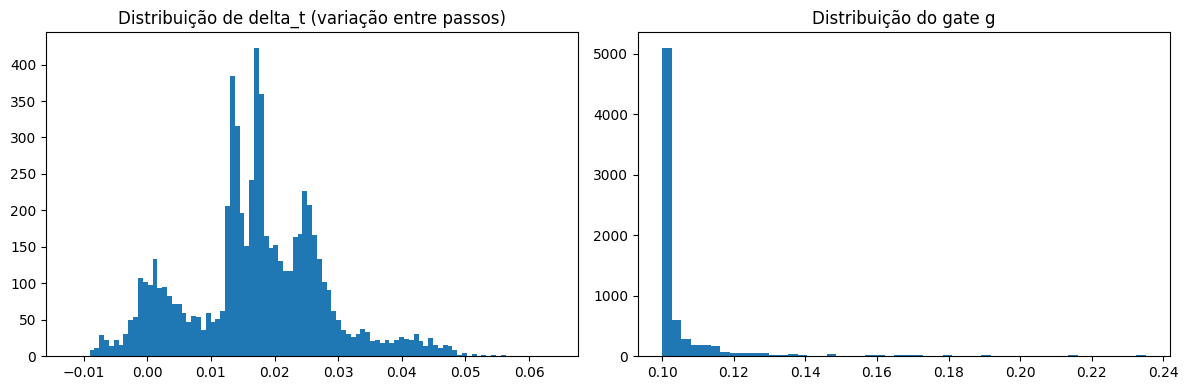

In [10]:
model.eval()
all_deltas = []
all_gates = []

with torch.no_grad():
    for batch in dl_test:
        b = move_sample_to_device(batch, DEVICE)
        preds, mask, g_seq = model(b, 0.0, meta["decoder_history"], meta["decoder_horizon"])
        
        # Delta real: variação entre passos consecutivos das previsões
        delta = preds[:, 1:, :] - preds[:, :-1, :]
        all_deltas.append(delta.cpu().numpy())
        
        if g_seq is not None:
            all_gates.append(g_seq.cpu().numpy())

deltas = np.concatenate(all_deltas).flatten()
gates  = np.concatenate(all_gates).flatten()

print(f"delta: mean={deltas.mean():.4f}  std={deltas.std():.4f}  "
      f"%neg={(deltas<0).mean()*100:.1f}%  %pos={(deltas>0).mean()*100:.1f}%")
print(f"gate:  mean={gates.mean():.3f}  min={gates.min():.3f}  max={gates.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deltas, bins=100)
axes[0].set_title("Distribuição de delta_t (variação entre passos)")
axes[1].hist(gates, bins=50)
axes[1].set_title("Distribuição do gate g")
plt.tight_layout()

delta — média: 1.0  mediana: 1.0  % negativo: 0.0%
gate  — média: 0.673  (0=ignora y_prev, 1=copia y_prev)


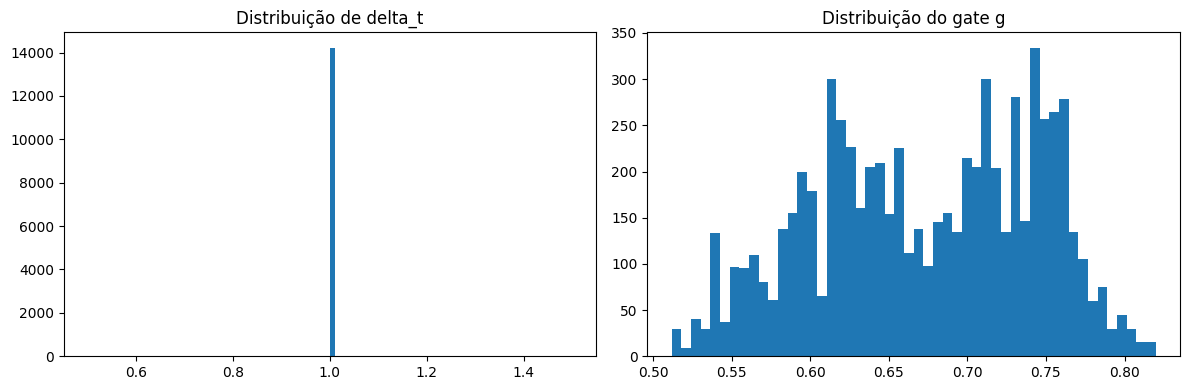

In [ ]:


model.eval()
all_deltas = []
all_gates  = []

with torch.no_grad():
    for batch in dl_test:
        b = move_sample_to_device(batch, DEVICE)
        # Exponha os valores internos — adicione hooks ou retorne delta/gate do forward
        _, delta, gate = model(b, 0.0, meta["decoder_history"], meta["decoder_horizon"])
        all_deltas.append(delta.cpu().numpy())   # shape (B, H, 1)
        all_gates.append(gate.cpu().numpy())

deltas = np.concatenate(all_deltas, axis=0).flatten()
gates  = np.concatenate(all_gates,  axis=0).flatten()

print(f"delta — média: {deltas.mean():.1f}  mediana: {np.median(deltas):.1f}  "
      f"% negativo: {(deltas < 0).mean()*100:.1f}%")
print(f"gate  — média: {gates.mean():.3f}  (0=ignora y_prev, 1=copia y_prev)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deltas, bins=100); axes[0].set_title("Distribuição de delta_t")
axes[1].hist(gates,  bins=50);  axes[1].set_title("Distribuição do gate g")
plt.tight_layout(); plt.savefig("delta_gate_audit.png", dpi=150)

In [11]:
# 1. Verificar a máscara
sample = test_ds[0]
print("mask_dec:", sample.mask_dec)
print("mask_dec sum:", sample.mask_dec.sum())
print("mask_dec shape:", sample.mask_dec.shape)

# 2. Verificar no dataset de treino
sample_train = train_ds[0]
print("\nmask_dec treino:", sample_train.mask_dec.sum())

# 3. Ver o delta_t real (requer modificar o forward temporariamente)
# No arquivo architecture.py, adicione um print dentro do loop:
# print(f"t={t} delta_t mean: {delta_t.mean().item():.4f}")

mask_dec: tensor([[1., 0., 1., 0., 0., 1.],
        [1., 0., 1., 0., 0., 1.],
        [1., 0., 1., 0., 0., 1.],
        [1., 0., 1., 0., 0., 1.],
        [1., 0., 1., 0., 0., 1.],
        [1., 0., 1., 0., 0., 1.],
        [1., 0., 1., 0., 0., 1.],
        [1., 1., 1., 0., 0., 1.],
        [1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 0., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
    

In [12]:
# diagnostic_delta.py
import numpy as np
import torch
import matplotlib.pyplot as plt

model.eval()
all_deltas = []
all_gates  = []

with torch.no_grad():
    for batch in val_ds:
        b = move_sample_to_device(batch, DEVICE)
        # Exponha os valores internos — adicione hooks ou retorne delta/gate do forward
        _, delta, gate = model(b, 0.0, meta["decoder_history"], meta["decoder_horizon"])
        all_deltas.append(delta.cpu().numpy())   # shape (B, H, 1)
        all_gates.append(gate.cpu().numpy())

deltas = np.concatenate(all_deltas, axis=0).flatten()
gates  = np.concatenate(all_gates,  axis=0).flatten()

print(f"delta — média: {deltas.mean():.1f}  mediana: {np.median(deltas):.1f}  "
      f"% negativo: {(deltas < 0).mean()*100:.1f}%")
print(f"gate  — média: {gates.mean():.3f}  (0=ignora y_prev, 1=copia y_prev)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deltas, bins=100); axes[0].set_title("Distribuição de delta_t")
axes[1].hist(gates,  bins=50);  axes[1].set_title("Distribuição do gate g")
plt.tight_layout(); plt.savefig("delta_gate_audit.png", dpi=150)

RuntimeError: For unbatched 2-D input, hx and cx should also be 2-D but got (3-D, 3-D) tensors

In [21]:
# diagnostic_delta.py
import numpy as np
import torch
import matplotlib.pyplot as plt

model.eval()
all_deltas = []
all_gates  = []

with torch.no_grad():
    for batch in val_ds:
        b = move_sample_to_device(batch, DEVICE)
        # Exponha os valores internos — adicione hooks ou retorne delta/gate do forward
        _, delta, gate = model(b, 0.0, meta["decoder_history"], meta["decoder_horizon"])
        all_deltas.append(delta.cpu().numpy())   # shape (B, H, 1)
        all_gates.append(gate.cpu().numpy())

deltas = np.concatenate(all_deltas, axis=0).flatten()
gates  = np.concatenate(all_gates,  axis=0).flatten()

print(f"delta — média: {deltas.mean():.1f}  mediana: {np.median(deltas):.1f}  "
      f"% negativo: {(deltas < 0).mean()*100:.1f}%")
print(f"gate  — média: {gates.mean():.3f}  (0=ignora y_prev, 1=copia y_prev)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deltas, bins=100); axes[0].set_title("Distribuição de delta_t")
axes[1].hist(gates,  bins=50);  axes[1].set_title("Distribuição do gate g")
plt.tight_layout(); plt.savefig("delta_gate_audit.png", dpi=150)

RuntimeError: For unbatched 2-D input, hx and cx should also be 2-D but got (3-D, 3-D) tensors

### Métricas

In [22]:
# 1. Gerais

metrics = compute_flow_metrics(
    preds=preds,
    obs=obs,
    stations=meta["stations"], # Use meta["stations"] aqui
    baseline_last=baseline
)

print_metrics_summary(metrics)
#save_metrics(metrics, experiment_name)

RESUMO DAS MÉTRICAS POR ESTAÇÃO
📍 Estação 10100000
------------------------------------------------------------
  Overall:
    RMSE:       1622.726 m³/s
    MAE:        1181.942 m³/s
    MAPE:       2.64%
    R²:         0.9664
    NSE:        0.9664
    KGE:        0.9339
    Skill RMSE: 0.3627
Macro (ponderado por horizonte):
    RMSE:       1460.965 m³/s
    MAE:        1181.942 m³/s
    MAPE:       2.64%
    R²:         0.9630
    NSE:        0.9630
📍 Estação 13150000
------------------------------------------------------------
  Overall:
    RMSE:       1988.556 m³/s
    MAE:        1456.882 m³/s
    MAPE:       1.69%
    R²:         0.9911
    NSE:        0.9911
    KGE:        0.9750
    Skill RMSE: 0.5538
Macro (ponderado por horizonte):
    RMSE:       1780.393 m³/s
    MAE:        1456.882 m³/s
    MAPE:       1.69%
    R²:         0.9906
    NSE:        0.9906
📍 Estação 14100000
------------------------------------------------------------
  Overall:
    RMSE:       2754.284 

CALCULANDO LIMIARES ANUAIS PARA EVENTOS EXTREMOS
📊 Estação 10100000:
  Máximas anuais: média=53050.45, std=3322.02
    Limiar EXTREMO (alta):  Q > 56372.47 m³/s
    Limiar MODERADO (alta): 53050.45 < Q < 56372.47 m³/s
  Mínimas anuais: média=18620.11, std=7441.79
    Limiar EXTREMO (baixa):  Q < 11178.32 m³/s
    Limiar MODERADO (baixa): 11178.32 < Q < 18620.11 m³/s
📊 Estação 13150000:
  Máximas anuais: média=117338.33, std=5569.37
    Limiar EXTREMO (alta):  Q > 122907.70 m³/s
    Limiar MODERADO (alta): 117338.33 < Q < 122907.70 m³/s
  Mínimas anuais: média=49436.73, std=10090.81
    Limiar EXTREMO (baixa):  Q < 39345.92 m³/s
    Limiar MODERADO (baixa): 39345.92 < Q < 49436.73 m³/s
📊 Estação 14100000:
  Máximas anuais: média=141232.56, std=7954.80
    Limiar EXTREMO (alta):  Q > 149187.36 m³/s
    Limiar MODERADO (alta): 141232.56 < Q < 149187.36 m³/s
  Mínimas anuais: média=57054.71, std=10097.43
    Limiar EXTREMO (baixa):  Q < 46957.28 m³/s
    Limiar MODERADO (baixa): 46957.28 <

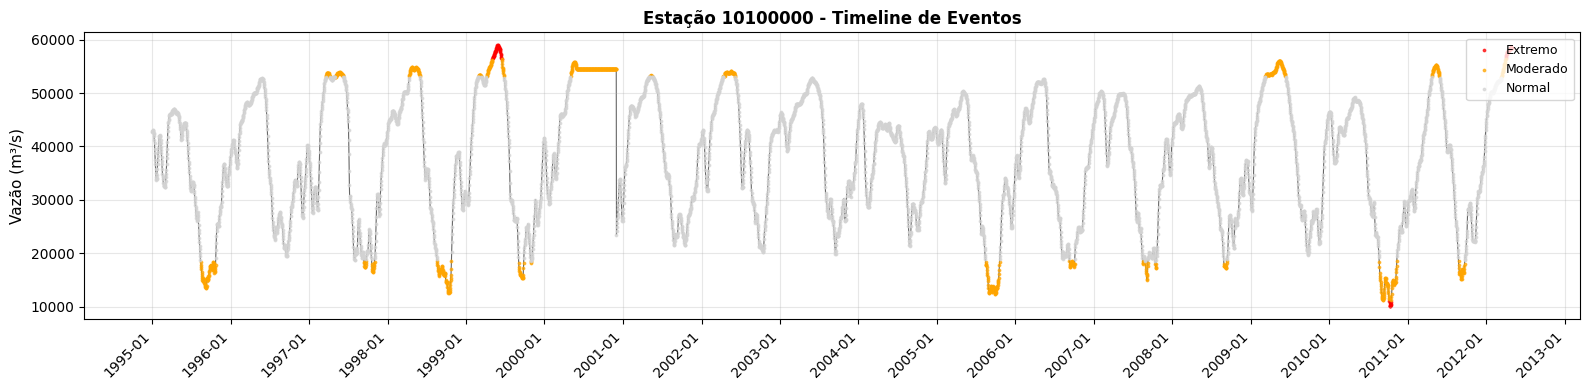

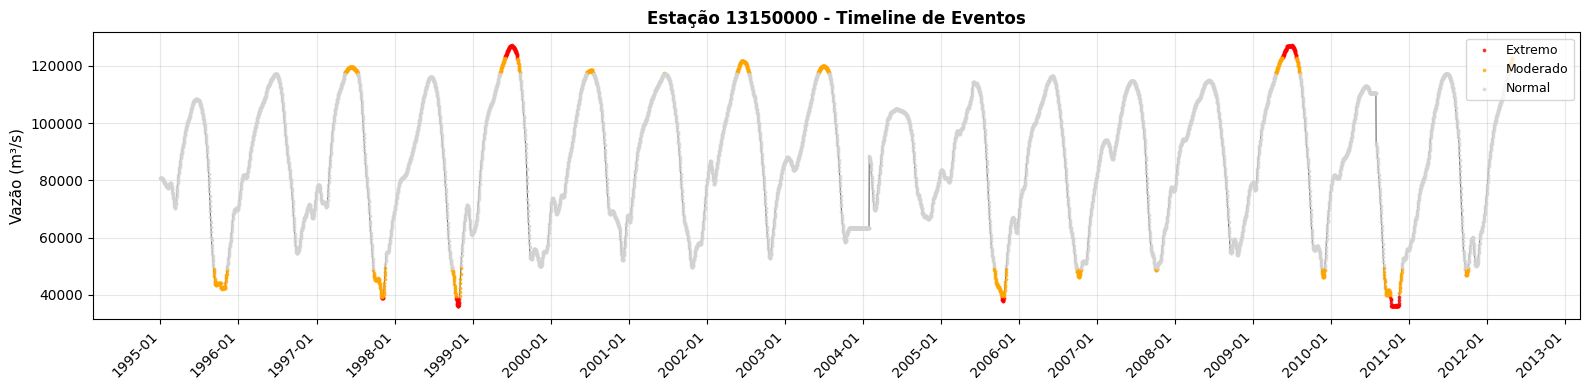

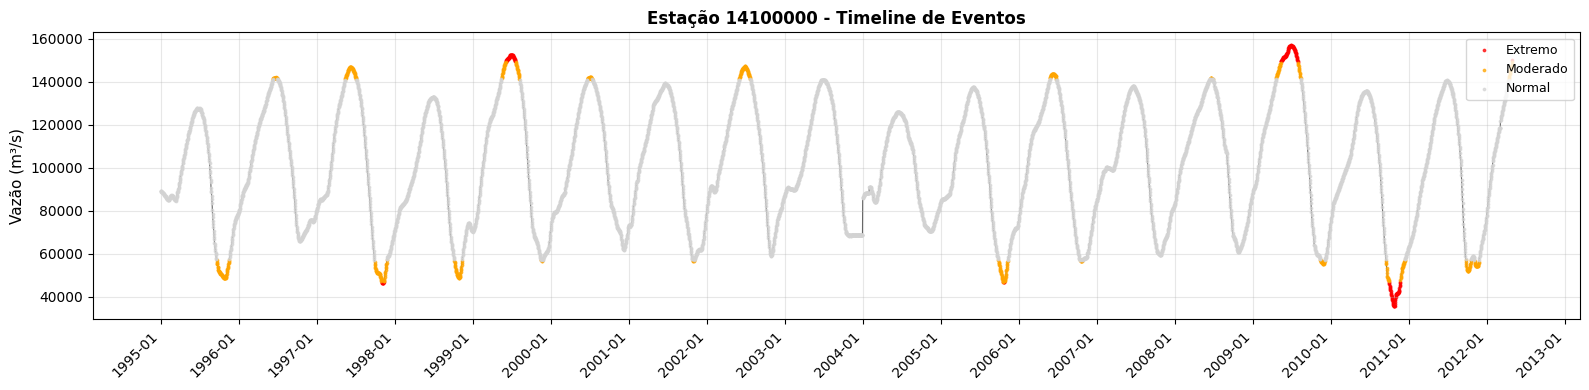

In [21]:
#  Por evento
# Obter window_indices
thresholds, classifications, window_indices = analyze_flow_extremes(
    df=combined_df,
    stations=stations,
    window_dates=dates,        # ← direto do predict_autoregressive
    flow_col_pattern="Q_{}"
)

#  Calcular métricas por tipo de evento
metrics_by_event = compute_metrics_by_event_type(
    preds=preds,
    obs=obs,
    stations=stations,
    window_indices=window_indices,
    baseline_last=baseline,
    horizon_weights=None
)

# 4. Salvar métricas
saved = save_metrics(
    metrics=metrics_by_event,
    experiment_name=experiment_name,
    filename_base="metrics_by_event"
)

💾 Plot salvo (test): exp_004_Operational_Framework_no_loss_direction/predictions_test/plots/metrics_by_horizon.png
💾 Plot salvo (test): exp_004_Operational_Framework_no_loss_direction/predictions_test/plots/full_series_d1.png


'\'\n# 3. Plotar e Salvar TODAS as janelas de previsão (ou amostras específicas)\n# Se quiser todas, deixe indices=None e n_samples=None na função refatorada\nfigs_context = plot_predictions_with_context(\n    preds, obs, stations, combined_df,dates,\n    context_days=30,     # Dias de histórico para mostrar\n    baseline_last=baseline,\n    g_seq=g_seq,\n    show=False\n)\n\n\nfor i, fig in enumerate(figs_context):\n    # Usamos a data da previsão no nome do arquivo para facilitar busca\n    date_str = pd.to_datetime(dates[i]).strftime(\'%Y%m%d\')\n    save_plot(fig, experiment_name, mode=MODE, name=f"forecast_idx{i}_{date_str}.png")\n    plt.close(fig) # Importante para não estourar a memória do notebook\n\n\n# 4. Plotar e Salvar Eventos Extremos (Máximos)\nfigs_extremes = plot_predictions_extremes(\n    preds, obs, stations, combined_df, dates,\n    n_samples=5, extreme_type=\'max\'\n)\n\nfor i, fig in enumerate(figs_extremes):\n    save_plot(fig, experiment_name, mode=MODE, name=f"

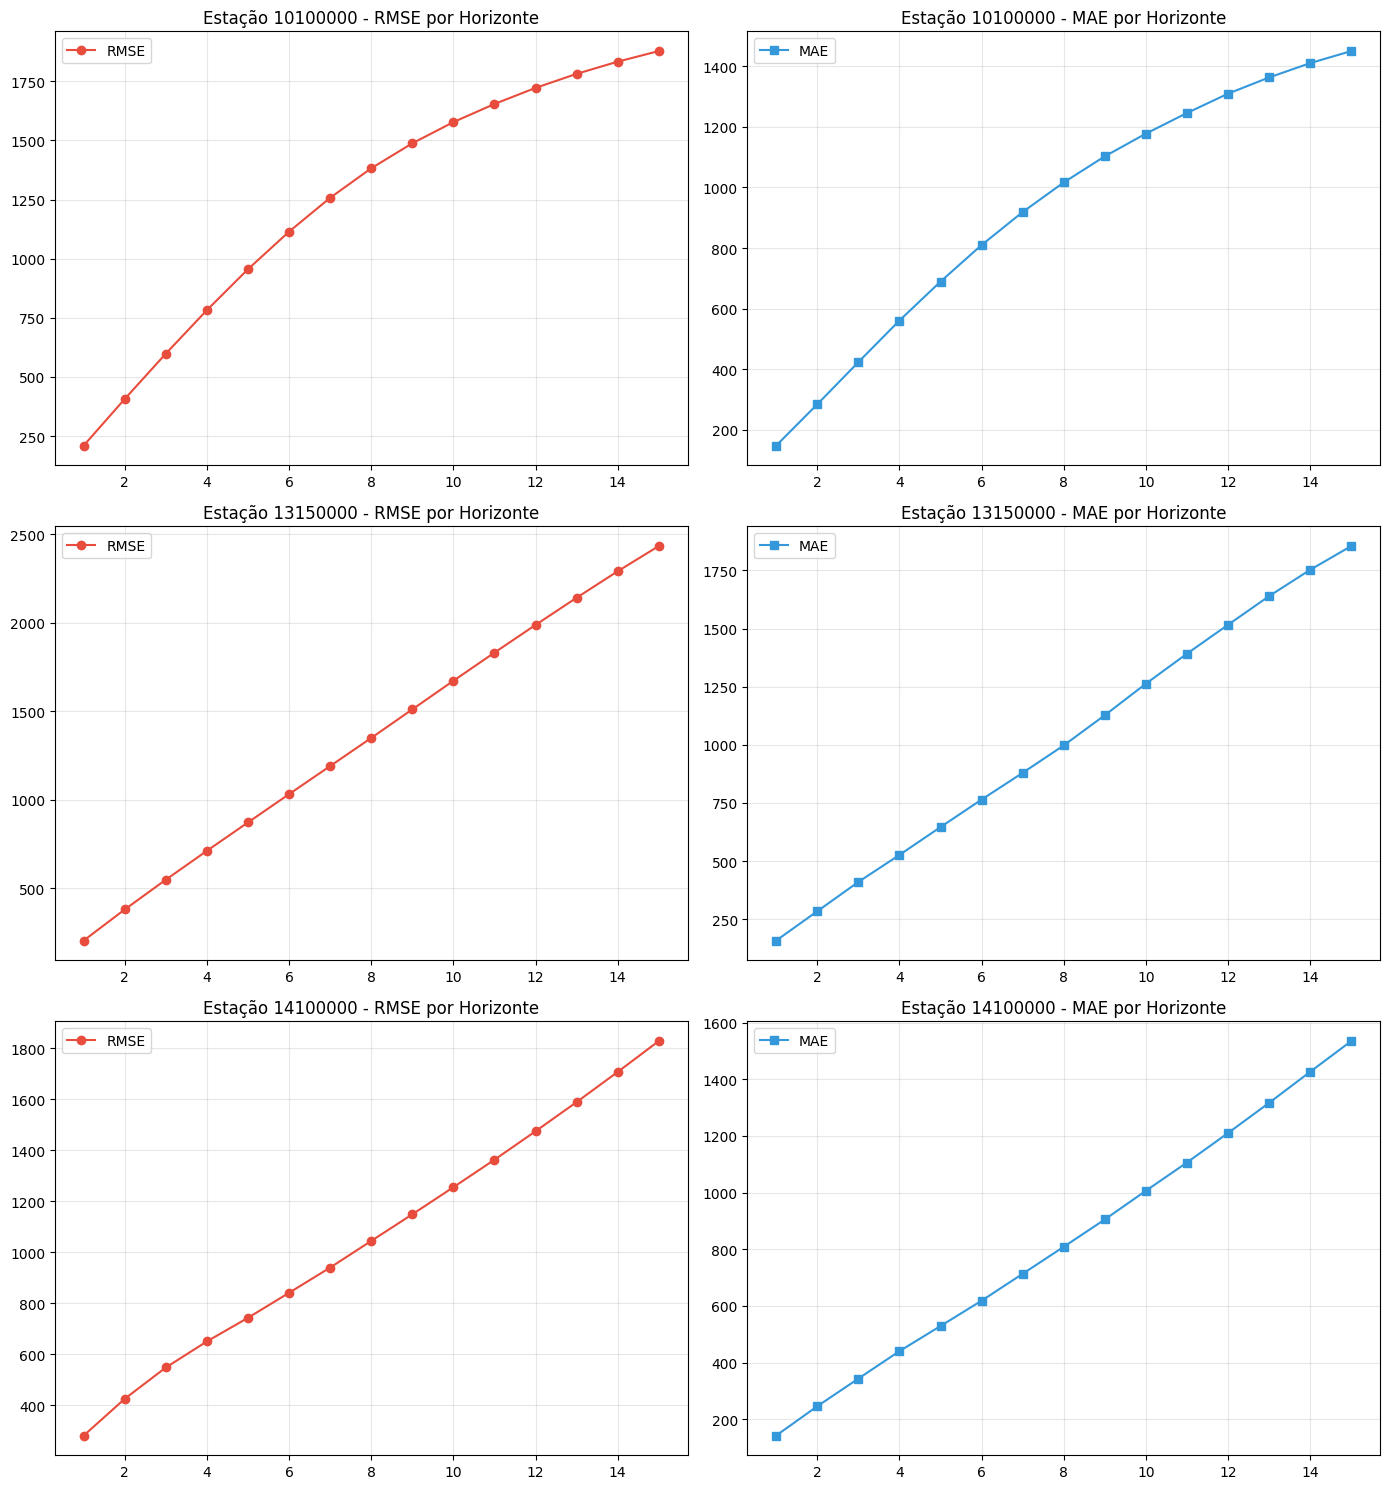

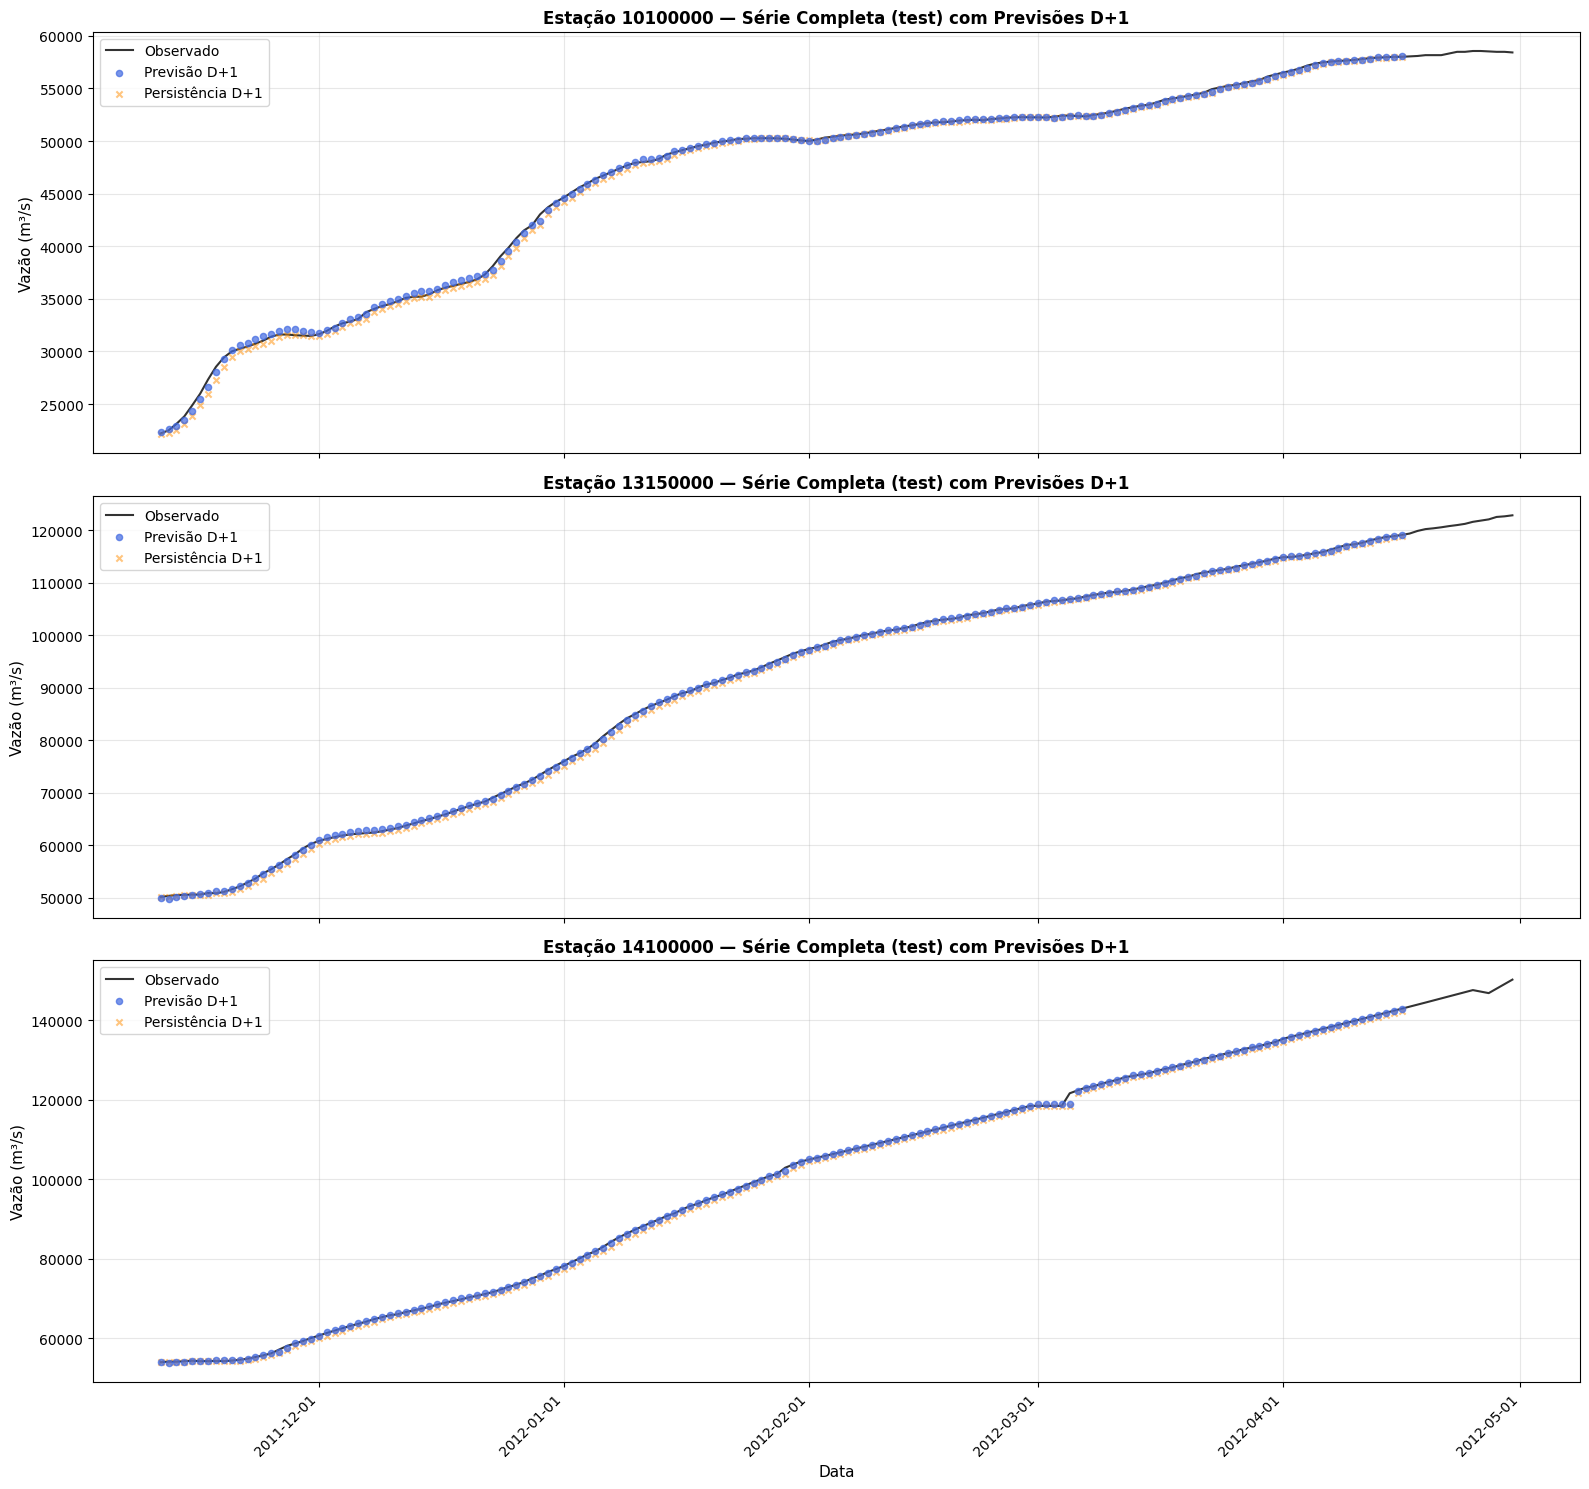

In [11]:
# --- CONFIGURAÇÕES ---
MODE = "test" # ou "operational"

# 1. Plotar e Salvar Métricas por Horizonte
fig_metrics = plot_metrics_by_horizon(
    metrics,
    stations
)
save_plot(fig_metrics, experiment_name, mode=MODE, name="metrics_by_horizon.png")


# 2. Plotar e Salvar Série Temporal D+1
fig_series = plot_full_series_with_d1_forecast(
    preds=preds,
    obs=obs,
    stations=stations,
    forecast_dates=dates,
    df=combined_df,
    period_name=MODE,
    baseline_last=baseline,
    figsize=(16, 5)
)
save_plot(fig_series, experiment_name, mode=MODE, name="full_series_d1.png")

''''
# 3. Plotar e Salvar TODAS as janelas de previsão (ou amostras específicas)
# Se quiser todas, deixe indices=None e n_samples=None na função refatorada
figs_context = plot_predictions_with_context(
    preds, obs, stations, combined_df,dates,
    context_days=30,     # Dias de histórico para mostrar
    baseline_last=baseline,
    g_seq=g_seq,
    show=False
)


for i, fig in enumerate(figs_context):
    # Usamos a data da previsão no nome do arquivo para facilitar busca
    date_str = pd.to_datetime(dates[i]).strftime('%Y%m%d')
    save_plot(fig, experiment_name, mode=MODE, name=f"forecast_idx{i}_{date_str}.png")
    plt.close(fig) # Importante para não estourar a memória do notebook


# 4. Plotar e Salvar Eventos Extremos (Máximos)
figs_extremes = plot_predictions_extremes(
    preds, obs, stations, combined_df, dates,
    n_samples=5, extreme_type='max'
)

for i, fig in enumerate(figs_extremes):
    save_plot(fig, experiment_name, mode=MODE, name=f"extreme_max_{i}.png")
    plt.close(fig)'''